# ANN - Regresión Caso Ecommerce

In [3]:
import pandas as pd
import numpy as np

## Lectura de Datos

In [4]:
df = pd.read_csv('Ecommerce.csv')

In [5]:
df.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


## Limpieza de Datos

In [7]:
df.isnull().sum()

,0
Email,0
Address,0
Avatar,0
Avg. Session Length,0
Time on App,0
Time on Website,0
Length of Membership,0
Yearly Amount Spent,0


## Planteamiento del modelo

In [8]:
X = df[['Avg. Session Length','Time on App','Time on Website','Length of Membership']]
y = df['Yearly Amount Spent']

## Preprocesamiento

Haremos lo siguiente:

*   Escalamiento



### Escalamiento

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_enc = scaler.fit_transform(X)

In [11]:
X_enc[:2]

array([[ 1.45635117,  0.60728003,  2.49358859,  0.55010651],
       [-1.13650215, -0.94946372,  0.20655573, -0.87092735]])

### Validacion Cruzada

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

### Arquitectura de la red neuronal

La arquitectura es un arte. En este caso, utilizaremos capas densas (fully connected)

*  Probar con activation: relu, tanh, linear
*  Probar optimizadores: Adam, SGD, RMSProp, Adagrad
*  Probar combinaciones de capas

In [33]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

In [15]:
#Lineal
model = Sequential()
model.add(Input(shape=(4,))) #capa de entrada
model.add(Dense(20, activation='linear')) #capa oculta
model.add(Dense(10, activation='linear')) #capa oculta
model.add(Dense(1, activation='linear')) #capa de salida

In [17]:
model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.01),
              metrics=['mae'])

### Visualización del modelo

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
X_train

array([[ 0.73314361, -0.13577217, -0.21368631,  0.10170962],
       [ 1.2354693 , -0.23133443, -0.74484059, -1.4185221 ],
       [-0.43903853,  1.95032608,  0.12883727,  0.53200325],
       ...,
       [-1.25125901, -1.17352219, -2.14231308, -0.40552112],
       [-0.79996391,  2.09460507, -0.03661911,  0.22900329],
       [-0.63283097, -0.6077061 ,  0.51486516, -0.94812651]])

### Entrenamiento

In [20]:

history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 258905.8906 - mae: 502.2723 - val_loss: 252507.2031 - val_mae: 497.7186
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 258411.2031 - mae: 501.8970 - val_loss: 251889.3438 - val_mae: 497.1790
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 257714.4375 - mae: 501.3471 - val_loss: 251055.1250 - val_mae: 496.4501
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 256816.2812 - mae: 500.6299 - val_loss: 249903.0781 - val_mae: 495.4413
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 255540.6250 - mae: 499.5949 - val_loss: 248393.2188 - val_mae: 494.1138
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 253787.3125 - mae: 498.1493 - val_loss: 246456.0000 - val_mae: 492.4039
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 251513.5156 - mae: 496.2885 - val_loss: 243954.4688 - val_mae: 490.1679
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 248706.4844 - mae: 493.9058 - val_loss:

## Evaluación

In [21]:
from sklearn.metrics import r2_score

In [38]:
y_pred_train = model.predict(X_train)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [41]:
r2_score(y_train,y_pred_train)

0.9842289183274674

In [25]:
X_test[:5]

array([[-0.98389768, -1.7162456 ,  1.96607598, -0.09907246],
       [-0.24657454,  0.76984401, -0.02863481,  0.31866608],
       [-1.61939847, -1.96417105,  0.97377785,  0.70605065],
       [-0.60880414,  1.41482827,  0.17668564, -0.59307224],
       [-1.6777514 , -1.06548707,  1.00448656, -0.10478212]])

In [34]:
y_pred_test = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [35]:
r2_score(y_test,y_pred_test)

0.9762376093408188

Para interpretar este ejemplo
R² train: 0.98
R² test:  0.976   ✅ excelente

otro caso
R² train: 0.99
R² test:  0.85   ⚠️ overfitting

## Evolución del entrenamiento

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

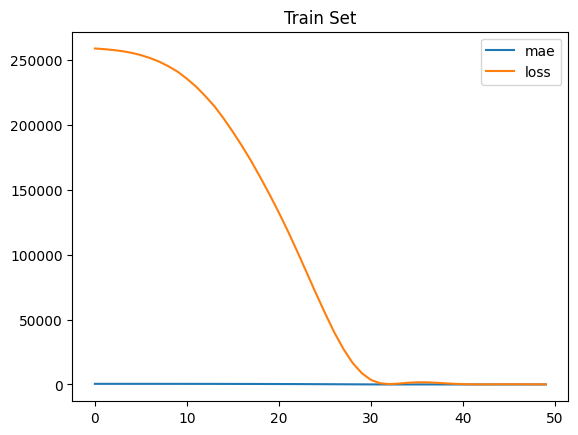

In [30]:
plt.title('Train Set')
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['loss'], label='loss')
plt.legend(loc=0)

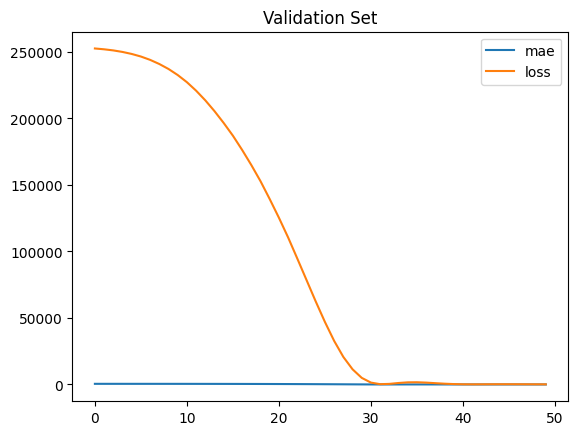

In [32]:
plt.title('Validation Set')
plt.plot(history.history['val_mae'], label='mae')
plt.plot(history.history['val_loss'], label='loss')
plt.legend(loc=0)